# LSCI 220 Assignment 1
## Dominic Kelly, Id 198511370

# Introduction
Rip It Up was a New Zealand music magazine that was launched in 1977 and finally ceased publication in 2015. It was the closest thing that the New Zealand contemporary music scene had to a *New Musical Express* or *Rolling Stone*. In 1988, John Dix wrote in Stranded In Paradise (a history of New Zealand Rock 'n Roll) "New Zealand's best promotional outlet for what's happening out there in the real world of rock'n'roll is neither radio nor television, but *Rip It Up*, a monthly freebie that refuses to die."

On November 11, 2025, it was announced that the Papers Past website now holds more than 20 years of free, searchable and downloadable [content](https://paperspast.natlib.govt.nz/periodicals/rip-it-up) from Rip It Up for the years 1977-1998.

I downloaded all the album reviews for Rip It Up's first five months of publication (June - October 1977) and for the five months starting on its 20th anniversary.

I made sure that each review's metadata (artist, album title etc) was formatted consistently. Since Papers Past provides an image of the printed page as well as the generated text, I corrected any errors that I could tell had been created during the scanning process, but *not* grammatical or spelling errors that were apparent in the original.

In [1]:
# some preliminary imports, setting up static data etc
from ast import pattern
import nltk
import string
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

from enum import Enum

class Year(Enum):
    Y1977 = 0
    Y1997 = 1

punctuation_set = set(string.punctuation)

# additional punctuation are pieces of text that I found were appearing in the results 
# that I would like to have been removed with other punctuation
additional_punctuation = set(["'s", "'m", "'", '.', '"', "n't","'ve",
                              '’', '“', '”', '’;', '’’', '.)',
                              '–', '—', '...', '``', "''", '‘', 
                              '•', '”.', '",', '”,', '.):', '":', '’)',
                              '.”', ".'", '’,','’),', '–,', '—,', '’.', 
                              '(‘', '".', ').', '."', "')", '!!'])

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('wordnet')
nltk.download('omw-1.4') 

lemmatizer = WordNetLemmatizer()
corpus_root = '.'  # Directory containing text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
tokeniser = nltk.tokenize.WordPunctTokenizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


The ```do_scrubbing()``` function below does five types of pre-processing that I want to apply to the corpora. By default all are applied, which is how it is used below.

In [2]:
# define a few functions.

def do_scrubbing(tokens: list, remove_punctuation=True, remove_additional_puctuation=True, remove_stopwords=True, lowercase=True, lemmatize=True) -> list:
    # Most of the cleaning out of punctuation, stopwords, plural forms etc, all in one place.
    print("Initial token count:", len(tokens))
    if lowercase:
        tokens = [token.lower() for token in tokens]
    if (remove_punctuation):
        tokens = [word for word in tokens if word not in punctuation_set]
        # tokens = [token.translate(str.maketrans('', '', string.punctuation)) for token in tokens]

    if remove_additional_puctuation:
        tokens = [word for word in tokens if word not in additional_punctuation]

    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    print("Final token count after scrubbing:", len(tokens))
    return tokens

# for analysing the text of the reviews, I prefer to exclude the headers that contain album and artist names, record labels and reviewer names
def remove_header_lines(body: str, pattern: str) -> str:
    lines = body.split('\n')
    reg_exp = re.compile(pattern)
    cleaned_lines = [line for line in lines if not reg_exp.search(line)]
    return '\n'.join(cleaned_lines)

def draw_wordcloud(frequencies: FreqDist, title: str):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(frequencies.most_common(20)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") # Turn off the axis labels
    plt.title(title)
    plt.show()

def normalise_frequencies(frequencies: FreqDist, token_count: int) -> FreqDist:
    normalized_frequencies = FreqDist()
    for word, freq in frequencies.items():
        norm_freq = freq / token_count * 100
        normalized_frequencies[word] = norm_freq
    return normalized_frequencies

In [3]:
# now the actual work

corpus = PlaintextCorpusReader(corpus_root, file_pattern)

raw_review_corpus = [None, None]
review_corpus = [None, None]
review_tokens = [None, None]
scrubbed_tokens = [None, None]
frequencies = [None, None]
normalised_frequencies = [None, None]

# Access the text

raw_review_corpus[Year.Y1977.value] = corpus.raw(['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt'])
raw_review_corpus[Year.Y1997.value] = corpus.raw(['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.txt', 'ALBUMS 97.09.01.txt', 'ALBUMS 97.10.01.txt'])

for year in [Year.Y1977.value, Year.Y1997.value]:
    review_corpus[year] = remove_header_lines(raw_review_corpus[year], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
    review_tokens[year] = tokeniser.tokenize(review_corpus[year])
    scrubbed_tokens[year] = do_scrubbing(review_tokens[year])
    

Initial token count: 28021
Final token count after scrubbing: 12800
Initial token count: 38467
Final token count after scrubbing: 17838
Final token count after scrubbing: 12800
Initial token count: 38467
Final token count after scrubbing: 17838


Before looking at frequencies, a few simple metrics:

In [4]:
from nltk.text import Text
import pandas as pd
raw_review_tokens = [None, None]
headings = ['Year', 'Token Count', 'Review Count', 'Paragraph Count', 'Paragraphs per Review', 'Tokens per Review', 'TTR']
data = []
for year in [Year.Y1977.value, Year.Y1997.value]:
    token_type_count = len(set(scrubbed_tokens[year]))
    token_count = len(scrubbed_tokens[year])
    TTR = token_type_count / token_count
    paragraphs = review_corpus[year].split('\n')
    num_paragraphs = len(paragraphs)
    tokens_per_paragraph = token_count / num_paragraphs
    raw_review_tokens[year] = tokeniser.tokenize(raw_review_corpus[year])
    num_non_reviews = review_tokens[year].count('reviewed')
    num_reviews = raw_review_tokens[year].count('Reviewed') - num_non_reviews
    paragraphs_per_review = num_paragraphs / num_reviews
    tokens_per_review = token_count / num_reviews
    data.append([year, token_count, num_reviews, num_paragraphs, paragraphs_per_review, tokens_per_review, TTR])

df = pd.DataFrame(data, columns=headings )
print(df)

   Year  Token Count  Review Count  Paragraph Count  Paragraphs per Review  \
0     0        12800            57              419               7.350877   
1     1        17838           156              341               2.185897   

   Tokens per Review       TTR  
0         224.561404  0.324531  
1         114.346154  0.347180  


This analysis seems to be saying that by 1997 there were nearly three times as many reviews in each publication, but each one was half as long, with far fewer paragraphs.

The Type/Token Ratio went up a little.

Now some **Frequencies**, with word clouds to aid with visualisation.

Most common words in Y1977 (normalised frequencies):
  album: 1.6%
  song: 1.1%
  one: 0.82%
  record: 0.79%
  band: 0.74%
  like: 0.69%
  music: 0.57%
  good: 0.55%
  rock: 0.54%
  vocal: 0.47%
  sound: 0.45%
  track: 0.42%
  first: 0.4%
  time: 0.38%
  love: 0.38%
  well: 0.37%
  guitar: 0.37%
  two: 0.34%
  group: 0.34%
  new: 0.34%


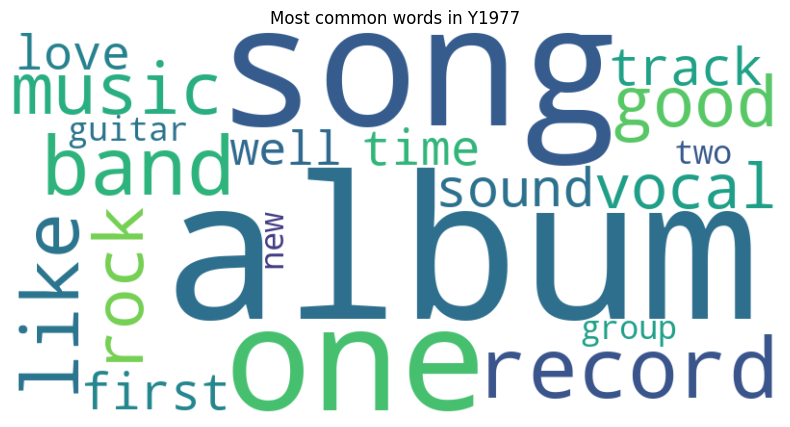

Most common words in Y1997 (normalised frequencies):
  album: 1.4%
  like: 0.85%
  song: 0.77%
  band: 0.64%
  sound: 0.62%
  rock: 0.59%
  one: 0.55%
  track: 0.45%
  new: 0.41%
  guitar: 0.38%
  music: 0.33%
  time: 0.33%
  vocal: 0.33%
  good: 0.33%
  much: 0.31%
  year: 0.3%
  first: 0.29%
  back: 0.28%
  make: 0.27%
  get: 0.27%


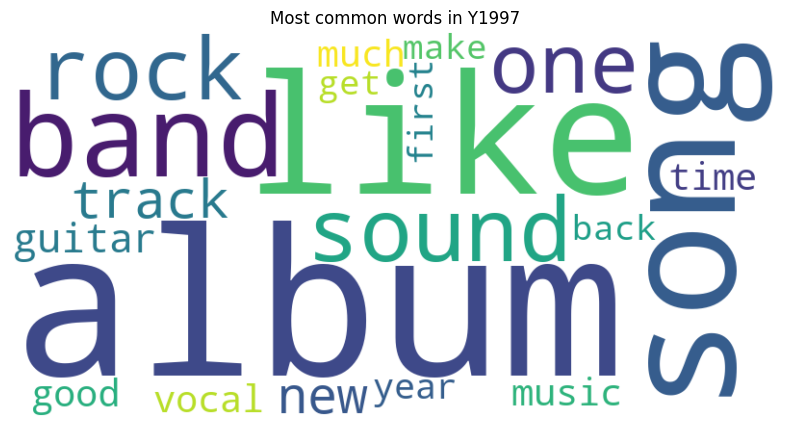

In [5]:

for year in [Year.Y1977.value, Year.Y1997.value]:
    frequencies[year] = FreqDist(scrubbed_tokens[year])
    token_count = len(scrubbed_tokens[year])
    # print(f"Most common words in {Year(year).name} (absolute frequencies):")
        # for word, freq in frequencies[year].most_common(20):
        #     print(f"  {word}: {freq}")
    # normalising becomes important when comparing corpora of different sizes
    print(f"Most common words in {Year(year).name} (normalised frequencies):")
    normalised_frequencies[year] = normalise_frequencies(frequencies[year], token_count)
    for word, freq in normalised_frequencies[year].most_common(20):
        print(f"  {word}: {freq:.2}%")
    most_common = frequencies[year].most_common(20)
    draw_wordcloud(frequencies[year], f"Most common words in {Year(year).name}")


I'd like to tell what vocabulary dropped out of use between 1977 and 1997 and what replaced it.

It turns out that a whole Frequency Distribution can be subtracted from another to produce a third, listing all the differences.

  record: 0.6%
  song: 0.4%
  group: 0.3%
  one: 0.3%
  music: 0.2%
  album: 0.2%
  good: 0.2%
  arrangement: 0.2%
  lyric: 0.2%
  love: 0.2%
  studio: 0.2%
  work: 0.2%
  disco: 0.2%
  rhythm: 0.2%
  however: 0.2%
  play: 0.2%
  never: 0.1%
  vocal: 0.1%
  side: 0.1%
  playing: 0.1%


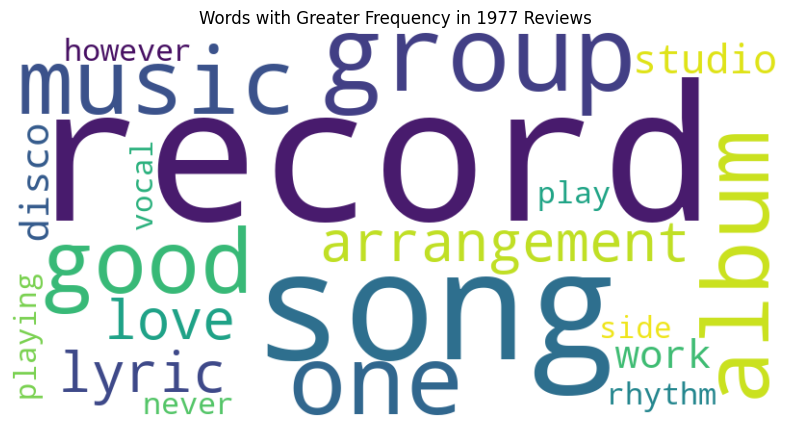

  sound: 0.2%
  like: 0.2%
  pop: 0.2%
  punk: 0.1%
  release: 0.1%
  yeah: 0.1%
  life: 0.1%
  label: 0.1%
  noise: 0.1%
  metal: 0.1%
  last: 0.1%
  sort: 0.1%
  much: 0.1%
  thing: 0.1%
  along: 0.1%
  way: 0.1%
  beat: 0.1%
  big: 0.1%
  disc: 0.1%
  far: 0.1%


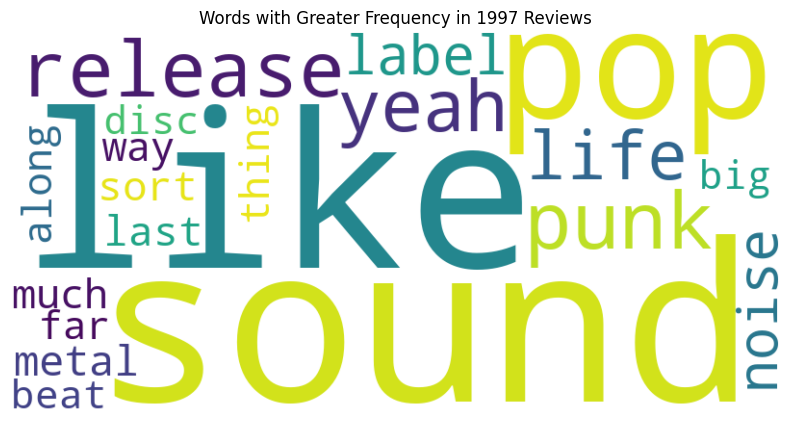

In [6]:

more_frequent_in_77 = normalised_frequencies[Year.Y1977.value] - normalised_frequencies[Year.Y1997.value]  # Words more common in first corpus
more_frequent_in_97 = normalised_frequencies[Year.Y1997.value] - normalised_frequencies[Year.Y1977.value]  # Words more common in second corpus

for word, freq in more_frequent_in_77.most_common(20):
    print(f"  {word}: {freq:.1f}%")
draw_wordcloud(FreqDist(more_frequent_in_77), "Words with Greater Frequency in 1977 Reviews")
for word, freq in more_frequent_in_97.most_common(20):
    print(f"  {word}: {freq:.1f}%")
draw_wordcloud(FreqDist(more_frequent_in_97), "Words with Greater Frequency in 1997 Reviews")

At first glance this process had produced some interesting results. But looking closer, some of the results look misleading. The word **album** dropped in frequency from 1.6% to 1.4%, and so made its way to number 6 in the list of words whose use had reduced between 1977 and 1997, even though it was still the single most frequently used word in both lists.

I concluded that even after normalising (and so accounting for any difference in sheer size of the two word lists), the differences in the frequencies over-emphasised any change for the most common words. Similarly, if a word was completely absent from one list but got a modest but meaningful amount of use in the other, it wouldn't necessarily appear at a particularly high position in this list of more frequently used words.

Some rummaging on the Internet suggested that a better way to determine the significance in change in use of a word between corpora was to calculate the **Log Likelihood**. It is [said](https://wordhoard.northwestern.edu/userman/analysis-comparewords.html) that the Log Likelihood "ratio measures the discrepancy of the the (sic) observed word frequencies from the values which we would expect to see if the word frequencies (by percentage) were the same in the two texts."

The code below works out which words generate the highest Log Likelihood values when their frequencies within the respective word lists are considered. Those whose LL value is above the threshold to be considered "highly significant" are appended to the list for the year in which they are (more significantly) present. Those words are then put in a word cloud with the LL value standing in for a frequency to determine how large to render that word.

Word with significantly changed use by Log-Likelihood scores:
  group: 56.13. From 43 to 3 appearances.
  record: 55.87. From 101 to 37 appearances.
  arrangement: 29.09. From 28 to 4 appearances.
  disco: 26.80. From 22 to 2 appearances.
  lofgren: 26.18. From 15 to 0 appearances.
  yeah: 24.88. From 0 to 23 appearances.
  george: 24.44. From 14 to 0 appearances.
  dolly: 20.95. From 12 to 0 appearances.
  feat: 19.20. From 11 to 0 appearances.
  miracle: 19.20. From 11 to 0 appearances.
  nil: 19.20. From 11 to 0 appearances.
  frampton: 19.20. From 11 to 0 appearances.
  studio: 18.76. From 29 to 9 appearances.
  punk: 17.59. From 3 to 30 appearances.
  gong: 17.46. From 10 to 0 appearances.
  winwood: 17.46. From 10 to 0 appearances.
  allmans: 17.46. From 10 to 0 appearances.
  disc: 17.31. From 0 to 16 appearances.
  metal: 16.33. From 1 to 21 appearances.
  label: 16.33. From 1 to 21 appearances.
  noise: 16.33. From 1 to 21 appearances.
  however: 15.74. From 25 to 8 appearance

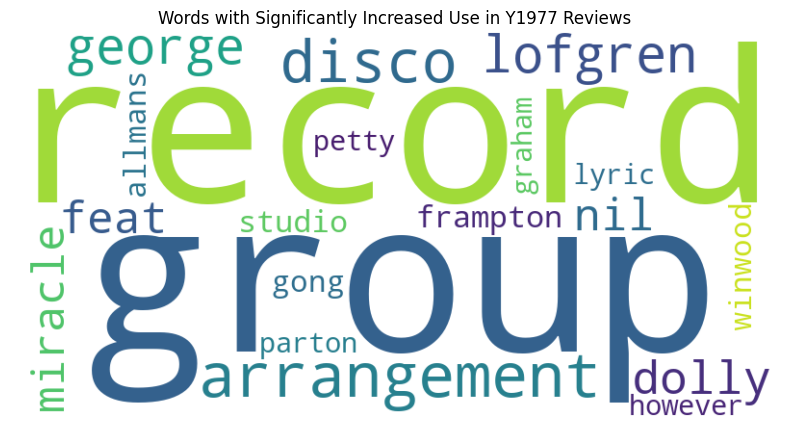

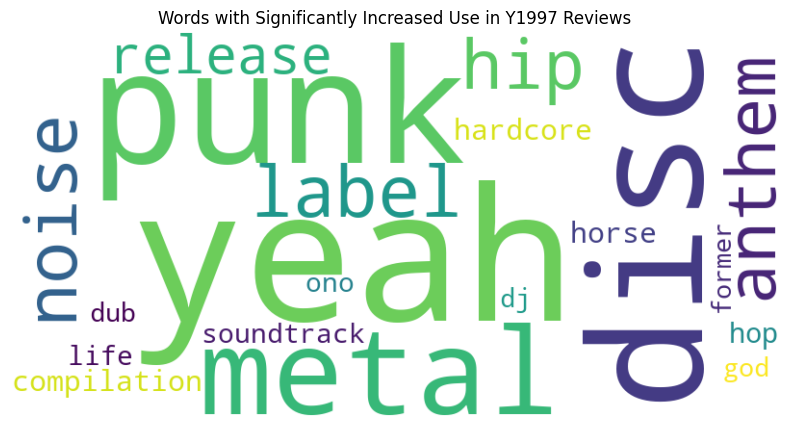

In [7]:
import math

def calculate_single_log_likelihood(a: int, b: int, c: int, d: int):
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    G_squared = 2*((a * math.log(a / E1) if a != 0 else 0) + (b * math.log(b / E2) if b != 0 else 0))
    return G_squared


def calculate_log_likelihoods(freq_1: FreqDist, word_count_1: int, freq_2: FreqDist, word_count_2: int):
    all_words = set(freq_1.keys()).union(set(freq_2.keys()))
    ll_scores = {}
    for word in all_words:
        # if (freq_1[word] > 10) | (freq_2[word] > 10):
        a = freq_1[word]
        b = freq_2[word]
        c = word_count_1
        d = word_count_2
        ll_scores[word] = calculate_single_log_likelihood(a, b, c, d)
    return ll_scores

increased_use = [[], []]

# note: back to using raw frequencies rather than normalised ones.
LLs = calculate_log_likelihoods(frequencies[Year.Y1977.value], len(scrubbed_tokens[Year.Y1977.value]), frequencies[Year.Y1997.value], len(scrubbed_tokens[Year.Y1997.value]))
sorted_LLs = sorted(LLs.items(), key=lambda x: x[1], reverse=True)
print("Word with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs:
    if (score > 6.63): # LL scores greater than 6.63 are considered highly significant
        print(f"  {word}: {score:.2f}. From {frequencies[Year.Y1977.value][word]} to {frequencies[Year.Y1997.value][word]} appearances.")
        if (normalised_frequencies[Year.Y1977.value][word] > normalised_frequencies[Year.Y1997.value][word]):
            increased_use[Year.Y1977.value].append((word, score))
        else:
            increased_use[Year.Y1997.value].append((word, score))

for year in [Year.Y1977.value, Year.Y1997.value]:
    word_freq_dist = FreqDist(dict(increased_use[year]))

    draw_wordcloud(word_freq_dist, "Words with Significantly Increased Use in " + Year(year).name + " Reviews")

These seem like more sensible results than the previous method was getting. 

Some observations:

* The reduction in the use of **record** is completely unsurprising and a sign that we're on the right - ahem - track. It is partly replaced by **disc**, although the increase in the use of disc isn't as high as the reduction in the use of record. The word **release** gets more use in the second corpus too. Perhaps critics were learning to distinguish the work from the format it was distributed in. But record doesn't completely go away and continues to be used, whether as a verb (i.e. recording an album), in conjunction with "company" or "label" or to *still* mean an album of music.

* Nearly as unsurprising as **record** is the demise of references to **disco**.

* What might be most interesting is that words like **arrangement**, **lyric**, **rhythm**, **percussion**, **melody** and **harmony** give way to words that identify musical genres, such as **genre** itself, **hardcore**, **metal**, **punk**, **hip** and (to a lesser degree) **hop**. Even the word **guitarist** goes from seventeen to seven appearances. One interpretation is that music criticism had become less concerned with the technicalities of music and recording and more with pigeon-holing music and listeners. This might also be explained by changes in the magazine's editorial policy and/or the personnel writing the reviews.

* The dramatic *increase* in the appearance of the word **punk** is surprising since Punk had just emerged in 1977. An explanation might be that while Punk was emerging there were few album releases for anyone to review. In 1997 though, Punk remained a topic of conversation through particular genres that had a high profile then.

Some of the LL scores *seemed* surprisingly high. For instance the word **one** went from 105 appearances in a corpus of 12830 words to 99 appearances in a corpus of 17796 and while this change looks insignificant at first glance, it gets a score of 7.57, suggesting that this is significant with better than 99% certainty. But maybe this score can be explained. In 1977 the fact that a record (or cassette!) had two *sides* made a difference to how people listened to music. It was a considered a work of two halves (well, sides). And occasionally four sides. By 1997 CDs dominated and it was rare to talk about Sides One and Two any more. The word **side** went from 32 appearances out of 12830 to 19 out of 17796 (for an LL value of 8.96). So it could be inferred that the reduction in **one**s correlates with the reduction in the uses of **side** and can justifiably be considered significant. I tested this below.

The following code extracts the use of "one" and "side".

In [8]:
for year in [Year.Y1977.value, Year.Y1997.value]:
    Text(review_tokens[year]).concordance('side', width=100, lines=32)
    Text(review_tokens[year]).concordance('one', width=100, lines=110)


Displaying 32 of 32 matches:
c is an overstatement as a title , although the side one chooses to listen to first does have a bear
conclusion . I strongly recommend you listen to side one first and if it appeals to you , stick to i
 complemented neatly by Chris Coppings ’ bass . Side two is a contrast , consisting of a work entitl
Gees are placed with a solid , danceable cut on side one , and a track on sjde two that could be a p
ing . Works is a double album set which gives a side to each member and a fourth side with Emerson ,
 which gives a side to each member and a fourth side with Emerson , Lake and Palmer together . Emers
 even operatic , as in “ Pirates " on the final side , but are not out of place here . " Hallowed Be
arrangements which sound awkward . On the third side Carl Palmer plays percussion to orchestral and 
' s " Fanfare For the Common Man " on the final side which is the most dramatic and impressive track
s that a gain ? Well , yes and no . On the plus side is " A Da

When I scrutinise the uses of the word **one** within the 1977 corpus, I can see that "side one" appears eight times, although one of them ("the side one chooses to listen to") is *not quite* with the meaning of "side one of a record". ("first side" appears four times as well.) "side two" appears three times (and "second side" appears four times).

So if we deduct that count of appearances of "one", in the 1977 corpus, by *seven*, and recalculate the Log Likelihood, the result goes from 7.58 to 4.93. It's still more than 95% likely to be significant, but drops down the leaderboard a little.

In [9]:
print(f"LL for \'one\' = {calculate_single_log_likelihood(105, 99, 12830, 17796):.2f}")
print(f"modified LL for \'one\' = {calculate_single_log_likelihood(98, 99, 12830, 17796):.2f}")

LL for 'one' = 7.58
modified LL for 'one' = 4.93


Looking at the uses of "one" generated by the concordance function, *ten* of those for the 1977 corpus are as the "indefinite pronoun", meaning "a person". E.g. "the side one chooses to listen to..." This particular usage reduces to *four* appearances for the 1997 corpus. 

It would be unsurprising if this usage, which might be considered formal, or even archaic, lost popularity between 1977 and 1997, particularly in a popular music magazine. This suggests making a couple more tests.

1. Is a change from ten uses in the 1977 corpus to four in the 1997 one significant?
2. If we further reduce the count of uses of "one" by ten and four respectively, what does this do to the Log Likelihood score?

In [10]:
print(f"LL for \'one\' as Impersonal Pronoun = {calculate_single_log_likelihood(10, 4, 12830, 17796):.2f}")
print(f"LL for \'one\' in Corpora after excluding use as Impersonal Pronoun AND as a Side of record = {calculate_single_log_likelihood(88, 95, 12830, 17796):.2f}")


LL for 'one' as Impersonal Pronoun = 4.99
LL for 'one' in Corpora after excluding use as Impersonal Pronoun AND as a Side of record = 2.85


To answer the questions above:
1. Yes, the reduced use of "one" as an impersonal pronoun is significant, with 95% certainty.
2. Discounting the frequency of the use of "one" by the number of times it refers to "side one" AND by the number of times it is used as an impersonal pronoun leaves a Log Likelihood score that suggests that its reduced use is *not* significant.

In other words, these Log Likelihood scores imply that the fact that **one** appears in the list of words whose use is significantly reduced between the 1977 and 1997 corpora can be explained by (1) the elimination of discussion of "sides" of a record AND (2) the reduction in the use of "one" as an impersonal pronoun.

Next: **yeah** appeared in the list of words whose use increased. What's going on?

In [11]:
for year in [Year.Y1977.value, Year.Y1997.value]:
    Text(review_tokens[year]).concordance('yeah', width=100, lines=30)
    print('------------------------------------')

no matches
------------------------------------
Displaying 23 of 23 matches:
 to this while I ' m reviewing it to find out . Yeah , yeah , I know that screaming on track one ’ s
s while I ' m reviewing it to find out . Yeah , yeah , I know that screaming on track one ’ s hard o
 Eric Clapton duel á la Derek and the Dominos … Yeah , the stage is set : relivin ’ that grey / gree
bye ’) and uptempo rock (‘ Wrong All Along ’, ‘ Yeah Yeah ’, ‘ Baby No More ’). Robin Zander ’ s voi
) and uptempo rock (‘ Wrong All Along ’, ‘ Yeah Yeah ’, ‘ Baby No More ’). Robin Zander ’ s voice is
metimes it forms the basis of a whole song . So yeah , Cake , they ’ re pretty quirky — all they rea
Misfits etc .), frustration , and unspecified ( yeah , right ) substances , they want your soul . No
 , irony ), where it ’ s so obviously lacking . Yeah , yeah , it ’ s all so fuckin ’ rock ‘ n ’ roll
y ), where it ’ s so obviously lacking . Yeah , yeah , it ’ s all so fuckin ’ rock ‘ n ’ roll , it ’
ng , self - de

We go from zero uses of "yeah" to 23.

It looks as though seven of the 23 **yeah**s come from quoting a single lyric, while there are three other instances of "yeah yeah".

## Critical Reflection

My objective here was to see what insights, quirks and statements of the obvious might be uncovered by using NLTK's tools to compare these two volumes of music reviews, separated by 20 years. And once I settled on the Log Likelihood method for evaluating the changes in frequency of individual words, there were plenty of results to ponder.

The Log Likelihood method was almost certainly an improvement on my first attempt, and the decision to use it came after becoming suspicious of the results of the previous method of calculating the differences between normalised frequencies. (As described in the commentary above.)

The league table of Log Likelihood scores revealed the most significant changes in vocabulary between the two corpora and these told me several things.

* The reduction in appearances between 1977 and 1997 of words like **record**, **side** and **disco** and the names of several musicians whose records were reviewed in the 1977 corpus was evidence that the method was producing sensible results.

* The appearance in that table of words like **one** and **yeah** provided puzzles that could be investigated by taking a closer look at how they were used within the text. NLTK provided the ```concordance()``` function which helped do that, but it then took human interpretation to tease apart the distinct uses of **one** that solved that particular mystery. **Group** is another one that would be good to look into when time permits.

* The replacement of words such as **arrangement**, **lyric** and **rhythm** with words that identify musical genres, such as **hardcore**, **metal** and **punk**, suggested that something about the nature of the reviews had changed.

This last issue might be the most enduring finding to come out of this exercise because I can think of more than one explanation, inviting further investigation.

* It could simply be that as Rip It Up's writers came and went, writing styles changed. This could be investigated by separating reviews by author and doing some more analysis.

* Another inference might be that Rip It Up magazine itself struggled with its status as the country's highest profile music magazine. In a commentary accompanying these past issues on the [Papers Past website](https://paperspast.natlib.govt.nz/periodicals/rip-it-up), it is mentioned that after 1998 the "fragmentation of musical genres meant that Rip It Up could no longer cover the entire music scene". Perhaps that comment is the theme of this analysis. As the first set of analyses showed, between 1977 and 1997 the number of albums reviewed grew nearly three times and the reviews got smaller. And this change of vocabulary might suggest that reviews became more perfunctory and coded to simplify things for a readership that was, itself, splitting into factions.

* Finally it could be inferred that music criticism in general changed between 1977 and 1997 and not just at Rip It Up. It was just before and during that period that disco, punk, hip hop and grunge appeared and the splintering and hybridising of styles haven't stopped. Perhaps critics came to believe that a priority was to put a new band or a new album into a category. If this is true then it will be apparent in reviews from other publications. It would be interesting to perform a similar analysis on reviews from overseas publications over a similar era. And what do you know? The University Library has a subscription to Proquest, giving me access to back issues of Rolling Stone and Billboard magazines - but not NME, sadly.

*Corpora created using the [Rip It Up magazine archive at Papers Past](https://paperspast.natlib.govt.nz/periodicals/rip-it-up).*
    
*This archive is licensed for non-commercial use under a Creative Commons Attribution Non-Commercial Share Alike 3.0 (CC BY-NC-SA 3.0) licence. Rip it Up is not available for commercial use without the consent of Propeller Lamont Ltd.*